

# **Question 3**

**Name:** Ankit BhagwatiPrasad Dhandharia

**CWID:** 20033031

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Set random seed for reproducibility
np.random.seed(42)

In [3]:
df = pd.read_csv('hepatitis_B2.csv')

In [4]:
df.shape

(40, 20)

In [5]:
df.head()

,Class,AGE,SEX,STEROID,ANTIVIRALS,FATIGUE,MALAISE,ANOREXIA,LIVER_BIG,LIVER_FIRM,SPLEEN_PALPABLE,SPIDERS,ASCITES,VARICES,BILIRUBIN,ALK_PHOSPHATE,SGOT,ALBUMIN,HISTOLOGY,Age_Quartile
0,1,39,1,1,1,1,1,2,2,1,2,2,2,2,2.3,280,98,3.8,1,Q2
1,1,37,1,2,2,1,2,2,2,2,2,1,2,2,0.6,67,28,4.2,1,Q2
2,1,58,1,2,2,1,2,2,1,1,1,1,2,2,2.0,167,242,3.3,1,Q4
3,1,30,1,2,2,1,1,1,2,1,2,1,1,1,2.5,165,64,2.8,2,Q1
4,1,38,1,1,2,1,1,1,2,1,2,1,1,1,1.2,118,16,2.8,2,Q2


In [6]:
df.isnull().sum()

Class              0
AGE                0
SEX                0
STEROID            0
ANTIVIRALS         0
FATIGUE            0
MALAISE            0
ANOREXIA           0
LIVER_BIG          0
LIVER_FIRM         0
SPLEEN_PALPABLE    0
SPIDERS            0
ASCITES            0
 VARICES           0
BILIRUBIN          0
ALK_PHOSPHATE      0
SGOT               0
ALBUMIN            0
HISTOLOGY          0
Age_Quartile       0
dtype: int64

In [7]:
df_clean = df.dropna()

In [8]:
# Select only the relevant features as specified in the problem
features = ['AGE', 'SEX', 'ASCITES', 'BILIRUBIN', 'ALK_PHOSPHATE', 'SGOT', 'ALBUMIN']
X = df_clean[features]
y = df_clean['Class']

In [9]:
# Display descriptive statistics for selected features
X.describe()

,AGE,SEX,ASCITES,BILIRUBIN,ALK_PHOSPHATE,SGOT,ALBUMIN
count,40.00000,40.000000,40.000000,40.000000,40.00000,40.000000,40.000000
mean,42.35000,1.100000,1.750000,1.490000,101.97500,71.825000,3.645000
std,11.86797,0.303822,0.438529,1.091647,51.05125,59.340775,0.651212
min,22.00000,1.000000,1.000000,0.400000,45.00000,16.000000,2.100000
25%,33.75000,1.000000,1.750000,0.775000,66.50000,28.000000,3.250000
50%,40.50000,1.000000,2.000000,1.100000,85.00000,54.000000,3.800000
75%,49.00000,1.000000,2.000000,2.000000,119.25000,91.250000,4.100000
max,78.00000,2.000000,2.000000,4.800000,280.00000,249.000000,4.900000


In [10]:
# Standardize the data for clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

In [11]:
X_scaled_df.head()

,AGE,SEX,ASCITES,BILIRUBIN,ALK_PHOSPHATE,SGOT,ALBUMIN
0,-0.285868,-0.333333,0.577350,0.751451,3.531606,0.446716,0.241050
1,-0.456536,-0.333333,0.577350,-0.825668,-0.693824,-0.747939,0.863114
2,1.335474,-0.333333,0.577350,0.473136,1.289946,2.904292,-0.536531
3,-1.053873,-0.333333,-1.732051,0.936994,1.250271,-0.133545,-1.314111
4,-0.371202,-0.333333,-1.732051,-0.269038,0.317899,-0.952737,-1.314111


## **Hierarchical Clustering**

In [12]:
# Calculate the linkage matrix using Ward method
Z = linkage(X_scaled, method='ward', metric='euclidean')

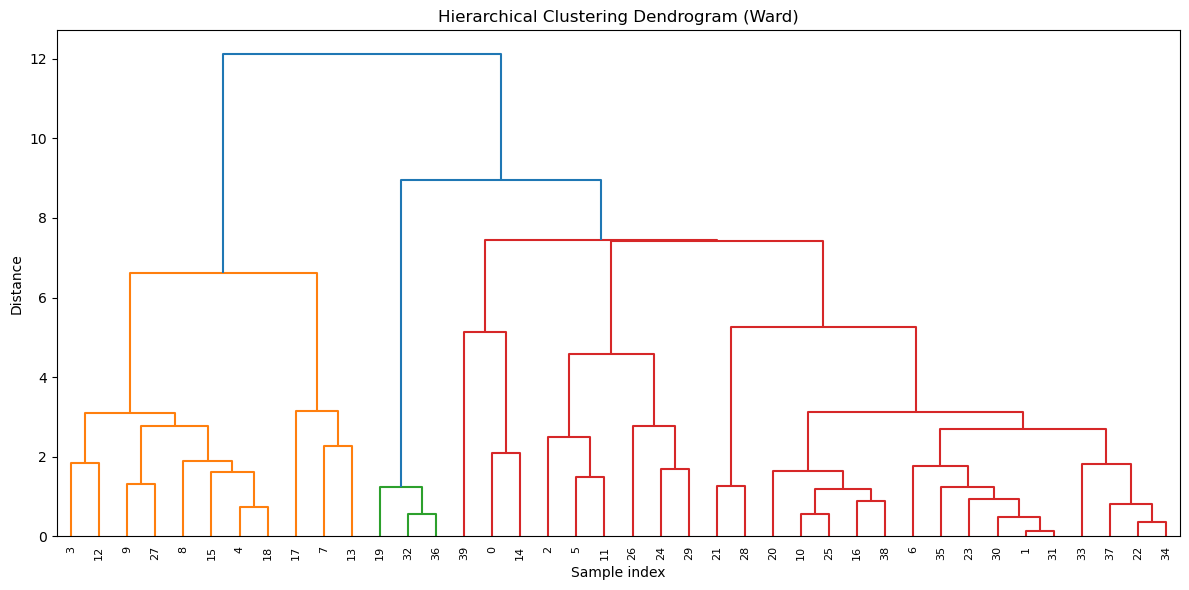

In [13]:
# Plot the dendrogram
plt.figure(figsize=(12, 6))
plt.title('Hierarchical Clustering Dendrogram (Ward)')
plt.xlabel('Sample index')
plt.ylabel('Distance')
dendrogram(Z, leaf_rotation=90, leaf_font_size=8)
plt.tight_layout()

In [14]:
# Perform hierarchical clustering with 2 clusters
hierarchical = AgglomerativeClustering(n_clusters=2, linkage='ward', metric='euclidean')
hierarchical_labels = hierarchical.fit_predict(X_scaled)

In [15]:
# Add hierarchical cluster labels to the dataframe
df_clean['Hierarchical_Cluster'] = hierarchical_labels

In [16]:
# Create a cross-tabulation of actual class vs. hierarchical clusters
hierarchical_cross_tab = pd.crosstab(
    df_clean['Class'], 
    df_clean['Hierarchical_Cluster'], 
    rownames=['Actual Class'], 
    colnames=['Hierarchical Cluster']
)

In [17]:
hierarchical_cross_tab

Hierarchical Cluster,0,1
Actual Class,,
1,9,10
2,20,1


In [18]:
# Calculate percentage distribution of each class within clusters
hierarchical_cross_tab_percent = pd.crosstab(
    df_clean['Class'], 
    df_clean['Hierarchical_Cluster'], 
    rownames=['Actual Class'], 
    colnames=['Hierarchical Cluster'],
    normalize='columns'
) * 100

In [19]:
# Percentage Distribution within Hierarchical Clusters
hierarchical_cross_tab_percent

Hierarchical Cluster,0,1
Actual Class,,
1,31.034483,90.909091
2,68.965517,9.090909


In [20]:
# Calculate Adjusted Rand Index (ARI) for hierarchical clustering
hierarchical_ari = adjusted_rand_score(y, hierarchical_labels)

In [21]:
hierarchical_ari

0.23398739025396265

In [22]:
# Calculate silhouette score for hierarchical clustering
hierarchical_silhouette = silhouette_score(X_scaled, hierarchical_labels)

In [23]:
hierarchical_silhouette

0.2904975290969881

## **K-means Clustering**

In [24]:
# Perform K-means clustering with 2 clusters
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

In [25]:
# Add K-means cluster labels to the dataframe
df_clean['KMeans_Cluster'] = kmeans_labels

In [26]:
# Create a cross-tabulation of actual class vs. K-means clusters
kmeans_cross_tab = pd.crosstab(
    df_clean['Class'], 
    df_clean['KMeans_Cluster'], 
    rownames=['Actual Class'], 
    colnames=['K-means Cluster']
)

In [27]:
kmeans_cross_tab

K-means Cluster,0,1
Actual Class,,
1,10,9
2,20,1
